In [1]:
# Import packages for data manipulation
# Import relevant libraries and modules.

import numpy as np
import pandas as pd



# This is the function that helps plot feature importance 
from xgboost import plot_importance

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

import matplotlib.pyplot as plt

# This displays all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# This module lets us save our models once we fit them.
import pickle

# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)


# This is the function that helps plot feature importance
from xgboost import plot_importance

# # This module lets us save our models once we fit them.
import pickle

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/oladayofolasire/mental-health-survey-2016/mental_heath_in_tech_2016.csv


In [2]:
# Read in data
file = '/kaggle/input/datasets/oladayofolasire/mental-health-survey-2016/mental_heath_in_tech_2016.csv'
df0 = pd.read_csv(file)
df0.head(10)

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you know local or online resources to seek help for a mental health disorder?,"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?","If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?","If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?","If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",Do you believe your productivity is ever affected by a mental health issue?,"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",Do you have previous employers?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Why or why not?,Would you bring up a mental health issue with a potential employer in an interview?,Why or why not?.1,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a menta

In [3]:
df0.columns

Index(['Are you self-employed?',
       'How many employees does your company or organization have?',
       'Is your employer primarily a tech company/organization?',
       'Is your primary role within your company related to tech/IT?',
       'Does your employer provide mental health benefits as part of healthcare coverage?',
       'Do you know the options for mental health care available under your employer-provided coverage?',
       'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?',
       'Does your employer offer resources to learn more about mental health concerns and options for seeking help?',
       'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
       'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:',
       'Do you think that dis

In [4]:
##make the colun label more shorter, friendly and descriptive##

# Make a copy first (recommended)
df = df0.copy()

# Rename columns to lowercase snake_case
df.rename(columns={
    'Are you self-employed?': 'self_employed',
    'How many employees does your company or organization have?': 'company_size',
    'Is your employer primarily a tech company/organization?': 'employer_tech',
    'Is your primary role within your company related to tech/IT?': 'role_tech_it',
    'Does your employer provide mental health benefits as part of healthcare coverage?': 'mh_benefits',
    'Do you know the options for mental health care available under your employer-provided coverage?': 'know_mh_coverage',
    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?': 'employer_discussed_mh',
    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?': 'mh_resources',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?': 'anonymity_protected',
    'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:': 'mh_leave_ease',
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?': 'mh_disclose_employer_neg',
    'Do you think that discussing a physical health issue with your employer would have negative consequences?': 'ph_disclose_employer_neg',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?': 'comfort_coworkers_mh',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?': 'comfort_supervisor_mh',
    'Do you feel that your employer takes mental health as seriously as physical health?': 'employer_mh_equals_ph',
    'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?': 'observed_mh_stigma_current',
    'Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?': 'mh_medical_coverage',
    'Do you know local or online resources to seek help for a mental health disorder?': 'know_mh_help_resources',
    'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?': 'reveal_mh_clients',
    'If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?': 'reveal_mh_clients_neg',
    'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?': 'reveal_mh_coworkers',
    'If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?': 'reveal_mh_coworkers_neg',
    'Do you believe your productivity is ever affected by a mental health issue?': 'mh_affects_productivity',
    'If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?': 'productivity_loss_percent',
    'Do you have previous employers?': 'previous_employers',
    'Have your previous employers provided mental health benefits?': 'prev_mh_benefits',
    'Were you aware of the options for mental health care provided by your previous employers?': 'prev_know_mh_coverage',
    'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?': 'prev_discussed_mh',
    'Did your previous employers provide resources to learn more about mental health issues and how to seek help?': 'prev_mh_resources',
    'Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?': 'prev_anonymity_protected',
    'Do you think that discussing a mental health disorder with previous employers would have negative consequences?': 'prev_mh_disclose_neg',
    'Do you think that discussing a physical health issue with previous employers would have negative consequences?': 'prev_ph_disclose_neg',
    'Would you have been willing to discuss a mental health issue with your previous co-workers?': 'prev_comfort_coworkers_mh',
    'Would you have been willing to discuss a mental health issue with your direct supervisor(s)?': 'prev_comfort_supervisor_mh',
    'Did you feel that your previous employers took mental health as seriously as physical health?': 'prev_employer_mh_equals_ph',
    'Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?': 'prev_observed_mh_stigma',
    'Would you be willing to bring up a physical health issue with a potential employer in an interview?': 'interview_disclose_ph',
    'Why or why not?': 'interview_ph_reason',
    'Would you bring up a mental health issue with a potential employer in an interview?': 'interview_disclose_mh',
    'Why or why not?.1': 'interview_mh_reason',
    'Do you feel that being identified as a person with a mental health issue would hurt your career?': 'mh_hurts_career',
    'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?': 'coworkers_view_mh_neg',
    'How willing would you be to share with friends and family that you have a mental illness?': 'share_mh_friends_family',
    'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?': 'observed_unsupportive_response',
    'Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?': 'less_likely_reveal_mh',
    'Do you have a family history of mental illness?': 'family_history_mh',
    'Have you had a mental health disorder in the past?': 'past_mh_disorder',
    'Do you currently have a mental health disorder?': 'current_mh_disorder',
    'If yes, what condition(s) have you been diagnosed with?': 'current_diagnosed_conditions',
    'If maybe, what condition(s) do you believe you have?': 'possible_conditions',
    'Have you been diagnosed with a mental health condition by a medical professional?': 'professional_mh_diagnosis',
    'If so, what condition(s) were you diagnosed with?': 'diagnosed_conditions',
    'Have you ever sought treatment for a mental health issue from a mental health professional?': 'sought_mh_treatment',
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?': 'work_impact_treated',
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?': 'work_impact_untreated',
    'What is your age?': 'age',
    'What is your gender?': 'gender',
    'What country do you live in?': 'country_live',
    'What US state or territory do you live in?': 'state_live_us',
    'What country do you work in?': 'country_work',
    'What US state or territory do you work in?': 'state_work_us',
    'Which of the following best describes your work position?': 'work_position',
    'Do you work remotely?': 'work_remotely'
}, inplace=True)

# Check renamed columns
print(df.columns.tolist())

['self_employed', 'company_size', 'employer_tech', 'role_tech_it', 'mh_benefits', 'know_mh_coverage', 'employer_discussed_mh', 'mh_resources', 'anonymity_protected', 'mh_leave_ease', 'mh_disclose_employer_neg', 'ph_disclose_employer_neg', 'comfort_coworkers_mh', 'comfort_supervisor_mh', 'employer_mh_equals_ph', 'observed_mh_stigma_current', 'Do you have medical coverage (private insurance or state-provided) which includes treatment of \xa0mental health issues?', 'know_mh_help_resources', 'reveal_mh_clients', 'reveal_mh_clients_neg', 'reveal_mh_coworkers', 'reveal_mh_coworkers_neg', 'mh_affects_productivity', 'productivity_loss_percent', 'previous_employers', 'prev_mh_benefits', 'prev_know_mh_coverage', 'prev_discussed_mh', 'prev_mh_resources', 'prev_anonymity_protected', 'prev_mh_disclose_neg', 'prev_ph_disclose_neg', 'prev_comfort_coworkers_mh', 'prev_comfort_supervisor_mh', 'prev_employer_mh_equals_ph', 'prev_observed_mh_stigma', 'interview_disclose_ph', 'interview_ph_reason', 'inter

In [5]:
pd.DataFrame({
    "Old Name": df0.columns,
    "New Name": df.columns
})

,Old Name,New Name
0,Are you self-employed?,self_employed
1,How many employees does your company or organi...,company_size
2,Is your employer primarily a tech company/orga...,employer_tech
3,Is your primary role within your company relat...,role_tech_it
4,Does your employer provide mental health benef...,mh_benefits
...,...,...
58,What US state or territory do you live in?,state_live_us
59,What country do you work in?,country_work
60,What US state or territory do you work in?,state_work_us
61,Which of the following best describes your wor...,work_position


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 63 columns):
 #   Column                                                                                                                 Non-Null Count  Dtype  
---  ------                                                                                                                 --------------  -----  
 0   self_employed                                                                                                          1433 non-null   int64  
 1   company_size                                                                                                           1146 non-null   object 
 2   employer_tech                                                                                                          1146 non-null   float64
 3   role_tech_it                                                                                                           263 non-null    float64
 4   

In [7]:
df.dtypes

self_employed      int64
company_size      object
employer_tech    float64
role_tech_it     float64
mh_benefits       object
                  ...   
state_live_us     object
country_work      object
state_work_us     object
work_position     object
work_remotely     object
Length: 63, dtype: object

In [8]:
df.shape

(1433, 63)

In [9]:
df.size

90279

In [10]:
df.head()

,self_employed,company_size,employer_tech,role_tech_it,mh_benefits,know_mh_coverage,employer_discussed_mh,mh_resources,anonymity_protected,mh_leave_ease,mh_disclose_employer_neg,ph_disclose_employer_neg,comfort_coworkers_mh,comfort_supervisor_mh,employer_mh_equals_ph,observed_mh_stigma_current,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,know_mh_help_resources,reveal_mh_clients,reveal_mh_clients_neg,reveal_mh_coworkers,reveal_mh_coworkers_neg,mh_affects_productivity,productivity_loss_percent,previous_employers,prev_mh_benefits,prev_know_mh_coverage,prev_discussed_mh,prev_mh_resources,prev_anonymity_protected,prev_mh_disclose_neg,prev_ph_disclose_neg,prev_comfort_coworkers_mh,prev_comfort_supervisor_mh,prev_employer_mh_equals_ph,prev_observed_mh_stigma,interview_disclose_ph,interview_ph_reason,interview_disclose_mh,interview_mh_reason,mh_hurts_career,coworkers_view_mh_neg,share_mh_friends_family,observed_unsupportive_response,less_likely_reveal_mh,family_history_mh,past_mh_disorder,current_mh_disorder,current_diagnosed_conditions,possible_conditions,professional_mh_diagnosis,diagnosed_conditions,sought_mh_treatment,work_impact_treated,work_impact_untreated,age,gender,country_live,state_live_us,country_work,state_work_us,work_position,work_remotely
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,NaN,Maybe,NaN,Maybe,"No, I don't think they would",Somewhat open,No,NaN,No,Yes,No,NaN,NaN,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,Maybe,Yes,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,NaN,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",NaN,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,NaN,NaN,No,NaN,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,"Yes, I know several","Sometimes, if it comes up",I'm not sure,"Sometimes, if it comes up",I'm not sure,Yes,1-25%,1,Some did,N/A (not currently aware),None did,None did,I don't know,Some of them,Some of them,Some of my previous employers,Some of my previous employers,I don't know,Some of them,Yes,"old back injury, doesn't cause me many issues ...",Maybe,would not if I was not 100% sure that the disc...,"Yes, I think it would",Maybe,Neutral,No,NaN,No,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",NaN,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Le

In [11]:
df.rename(columns={
    'Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?': 'mh_coverage'
}, inplace=True)

In [12]:
df.head()

,self_employed,company_size,employer_tech,role_tech_it,mh_benefits,know_mh_coverage,employer_discussed_mh,mh_resources,anonymity_protected,mh_leave_ease,mh_disclose_employer_neg,ph_disclose_employer_neg,comfort_coworkers_mh,comfort_supervisor_mh,employer_mh_equals_ph,observed_mh_stigma_current,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,know_mh_help_resources,reveal_mh_clients,reveal_mh_clients_neg,reveal_mh_coworkers,reveal_mh_coworkers_neg,mh_affects_productivity,productivity_loss_percent,previous_employers,prev_mh_benefits,prev_know_mh_coverage,prev_discussed_mh,prev_mh_resources,prev_anonymity_protected,prev_mh_disclose_neg,prev_ph_disclose_neg,prev_comfort_coworkers_mh,prev_comfort_supervisor_mh,prev_employer_mh_equals_ph,prev_observed_mh_stigma,interview_disclose_ph,interview_ph_reason,interview_disclose_mh,interview_mh_reason,mh_hurts_career,coworkers_view_mh_neg,share_mh_friends_family,observed_unsupportive_response,less_likely_reveal_mh,family_history_mh,past_mh_disorder,current_mh_disorder,current_diagnosed_conditions,possible_conditions,professional_mh_diagnosis,diagnosed_conditions,sought_mh_treatment,work_impact_treated,work_impact_untreated,age,gender,country_live,state_live_us,country_work,state_work_us,work_position,work_remotely
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,NaN,Maybe,NaN,Maybe,"No, I don't think they would",Somewhat open,No,NaN,No,Yes,No,NaN,NaN,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,Maybe,Yes,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,NaN,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",NaN,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,NaN,NaN,No,NaN,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,"Yes, I know several","Sometimes, if it comes up",I'm not sure,"Sometimes, if it comes up",I'm not sure,Yes,1-25%,1,Some did,N/A (not currently aware),None did,None did,I don't know,Some of them,Some of them,Some of my previous employers,Some of my previous employers,I don't know,Some of them,Yes,"old back injury, doesn't cause me many issues ...",Maybe,would not if I was not 100% sure that the disc...,"Yes, I think it would",Maybe,Neutral,No,NaN,No,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",NaN,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Le

In [13]:
print(df.columns.tolist())

['self_employed', 'company_size', 'employer_tech', 'role_tech_it', 'mh_benefits', 'know_mh_coverage', 'employer_discussed_mh', 'mh_resources', 'anonymity_protected', 'mh_leave_ease', 'mh_disclose_employer_neg', 'ph_disclose_employer_neg', 'comfort_coworkers_mh', 'comfort_supervisor_mh', 'employer_mh_equals_ph', 'observed_mh_stigma_current', 'Do you have medical coverage (private insurance or state-provided) which includes treatment of \xa0mental health issues?', 'know_mh_help_resources', 'reveal_mh_clients', 'reveal_mh_clients_neg', 'reveal_mh_coworkers', 'reveal_mh_coworkers_neg', 'mh_affects_productivity', 'productivity_loss_percent', 'previous_employers', 'prev_mh_benefits', 'prev_know_mh_coverage', 'prev_discussed_mh', 'prev_mh_resources', 'prev_anonymity_protected', 'prev_mh_disclose_neg', 'prev_ph_disclose_neg', 'prev_comfort_coworkers_mh', 'prev_comfort_supervisor_mh', 'prev_employer_mh_equals_ph', 'prev_observed_mh_stigma', 'interview_disclose_ph', 'interview_ph_reason', 'inter

In [14]:
df.columns = df.columns.str.replace('\xa0', ' ', regex=False).str.strip()

In [15]:
df.rename(columns={
    'Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?': 'mh_coverage'
}, inplace=True)

In [16]:
print(df.columns.tolist())

['self_employed', 'company_size', 'employer_tech', 'role_tech_it', 'mh_benefits', 'know_mh_coverage', 'employer_discussed_mh', 'mh_resources', 'anonymity_protected', 'mh_leave_ease', 'mh_disclose_employer_neg', 'ph_disclose_employer_neg', 'comfort_coworkers_mh', 'comfort_supervisor_mh', 'employer_mh_equals_ph', 'observed_mh_stigma_current', 'Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?', 'know_mh_help_resources', 'reveal_mh_clients', 'reveal_mh_clients_neg', 'reveal_mh_coworkers', 'reveal_mh_coworkers_neg', 'mh_affects_productivity', 'productivity_loss_percent', 'previous_employers', 'prev_mh_benefits', 'prev_know_mh_coverage', 'prev_discussed_mh', 'prev_mh_resources', 'prev_anonymity_protected', 'prev_mh_disclose_neg', 'prev_ph_disclose_neg', 'prev_comfort_coworkers_mh', 'prev_comfort_supervisor_mh', 'prev_employer_mh_equals_ph', 'prev_observed_mh_stigma', 'interview_disclose_ph', 'interview_ph_reason', 'intervie

In [17]:
df.head()

,self_employed,company_size,employer_tech,role_tech_it,mh_benefits,know_mh_coverage,employer_discussed_mh,mh_resources,anonymity_protected,mh_leave_ease,mh_disclose_employer_neg,ph_disclose_employer_neg,comfort_coworkers_mh,comfort_supervisor_mh,employer_mh_equals_ph,observed_mh_stigma_current,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,know_mh_help_resources,reveal_mh_clients,reveal_mh_clients_neg,reveal_mh_coworkers,reveal_mh_coworkers_neg,mh_affects_productivity,productivity_loss_percent,previous_employers,prev_mh_benefits,prev_know_mh_coverage,prev_discussed_mh,prev_mh_resources,prev_anonymity_protected,prev_mh_disclose_neg,prev_ph_disclose_neg,prev_comfort_coworkers_mh,prev_comfort_supervisor_mh,prev_employer_mh_equals_ph,prev_observed_mh_stigma,interview_disclose_ph,interview_ph_reason,interview_disclose_mh,interview_mh_reason,mh_hurts_career,coworkers_view_mh_neg,share_mh_friends_family,observed_unsupportive_response,less_likely_reveal_mh,family_history_mh,past_mh_disorder,current_mh_disorder,current_diagnosed_conditions,possible_conditions,professional_mh_diagnosis,diagnosed_conditions,sought_mh_treatment,work_impact_treated,work_impact_untreated,age,gender,country_live,state_live_us,country_work,state_work_us,work_position,work_remotely
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,NaN,Maybe,NaN,Maybe,"No, I don't think they would",Somewhat open,No,NaN,No,Yes,No,NaN,NaN,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,Maybe,Yes,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,NaN,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",NaN,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,NaN,NaN,No,NaN,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,"Yes, I know several","Sometimes, if it comes up",I'm not sure,"Sometimes, if it comes up",I'm not sure,Yes,1-25%,1,Some did,N/A (not currently aware),None did,None did,I don't know,Some of them,Some of them,Some of my previous employers,Some of my previous employers,I don't know,Some of them,Yes,"old back injury, doesn't cause me many issues ...",Maybe,would not if I was not 100% sure that the disc...,"Yes, I think it would",Maybe,Neutral,No,NaN,No,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",NaN,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Le

In [18]:
suspected_cols = [
    'interview_ph_reason',
    'interview_mh_reason',
    'current_diagnosed_conditions',
    'possible_conditions',
    'diagnosed_conditions'
]

for col in suspected_cols:
    print(f"\n{'='*80}")
    print(f"Column: {col}")
    print(f"{'='*80}")
    print("Unique count:", df[col].nunique(dropna=False))
    print("\nTop values:")
    print(df[col].value_counts(dropna=False).head(30))
    print("\nSample unique values:")
    print(df[col].dropna().astype(str).unique()[:30])


Column: interview_ph_reason
Unique count: 1086

Top values:
interview_ph_reason
NaN                                                                                                                                                                                                                                                                                                                              338
Not relevant                                                                                                                                                                                                                                                                                                                       3
Fear of discrimination                                                                                                                                                                                                                                                       

In [19]:
df.dtypes

self_employed      int64
company_size      object
employer_tech    float64
role_tech_it     float64
mh_benefits       object
                  ...   
state_live_us     object
country_work      object
state_work_us     object
work_position     object
work_remotely     object
Length: 63, dtype: object

In [20]:
##less_likely_reveal_mh (binary/ordinal: whether they would avoid disclosing a mental health condition at work) – reflects perceived stigma. mh_hurts_career (ordinal: whether mental health affects career progression) – shows perceived workplace barriers. comfort_supervisor_mh or comfort_coworkers_mh (ordinal: comfort level in disclosure) – indicates openness and workplace culture.##

In [21]:
df.isna().sum()

self_employed       0
company_size      287
employer_tech     287
role_tech_it     1170
mh_benefits       287
                 ... 
state_live_us     593
country_work        0
state_work_us     582
work_position       0
work_remotely       0
Length: 63, dtype: int64

In [22]:
df.shape
df.dropna().shape

(0, 63)

In [23]:
##Drops only rows where current_mh_disorder is missing, keeping all other rows intact.##

df = df.dropna(subset=['current_mh_disorder'])

In [24]:
# Fill categorical columns
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna('Missing')

# Fill numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [25]:
df.isna().sum().sort_values(ascending=False).head(20)

self_employed                                                                                                            0
company_size                                                                                                             0
employer_tech                                                                                                            0
role_tech_it                                                                                                             0
mh_benefits                                                                                                              0
know_mh_coverage                                                                                                         0
employer_discussed_mh                                                                                                    0
mh_resources                                                                                                             0
anonymity_protec

In [26]:
df.isna().sum()

self_employed    0
company_size     0
employer_tech    0
role_tech_it     0
mh_benefits      0
                ..
state_live_us    0
country_work     0
state_work_us    0
work_position    0
work_remotely    0
Length: 63, dtype: int64

In [27]:
# Replace with your chosen Y
y_col = 'current_mh_disorder'

# Check classes, counts, and proportions
print("Unique classes:")
print(df[y_col].unique())

print("\nClass counts:")
print(df[y_col].value_counts(dropna=False))

print("\nClass proportions:")
print(df[y_col].value_counts(normalize=True, dropna=False) * 100)

print("\nNumber of unique classes:")
print(df[y_col].nunique(dropna=False))

Unique classes:
['No' 'Yes' 'Maybe']

Class counts:
current_mh_disorder
Yes      575
No       531
Maybe    327
Name: count, dtype: int64

Class proportions:
current_mh_disorder
Yes      40.125611
No       37.055129
Maybe    22.819260
Name: proportion, dtype: float64

Number of unique classes:
3


In [28]:
df['current_mh_disorder_binary'] = df['current_mh_disorder'].map({'Yes': 1, 'No': 0, 'Maybe': 0}).astype(int)

In [29]:
df.head()

,self_employed,company_size,employer_tech,role_tech_it,mh_benefits,know_mh_coverage,employer_discussed_mh,mh_resources,anonymity_protected,mh_leave_ease,mh_disclose_employer_neg,ph_disclose_employer_neg,comfort_coworkers_mh,comfort_supervisor_mh,employer_mh_equals_ph,observed_mh_stigma_current,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,know_mh_help_resources,reveal_mh_clients,reveal_mh_clients_neg,reveal_mh_coworkers,reveal_mh_coworkers_neg,mh_affects_productivity,productivity_loss_percent,previous_employers,prev_mh_benefits,prev_know_mh_coverage,prev_discussed_mh,prev_mh_resources,prev_anonymity_protected,prev_mh_disclose_neg,prev_ph_disclose_neg,prev_comfort_coworkers_mh,prev_comfort_supervisor_mh,prev_employer_mh_equals_ph,prev_observed_mh_stigma,interview_disclose_ph,interview_ph_reason,interview_disclose_mh,interview_mh_reason,mh_hurts_career,coworkers_view_mh_neg,share_mh_friends_family,observed_unsupportive_response,less_likely_reveal_mh,family_history_mh,past_mh_disorder,current_mh_disorder,current_diagnosed_conditions,possible_conditions,professional_mh_diagnosis,diagnosed_conditions,sought_mh_treatment,work_impact_treated,work_impact_untreated,age,gender,country_live,state_live_us,country_work,state_work_us,work_position,work_remotely,current_mh_disorder_binary
0,0,26-100,1.0,1.0,Not eligible for coverage / N/A,Missing,No,No,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,Missing,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Sometimes,0
1,0,6-25,1.0,1.0,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,Maybe,Yes,Yes,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,Missing,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,1
2,0,6-25,1.0,1.0,No,Missing,No,No,I don't know,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,Missing,Missing,No,Missing,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Always,0
3,1,Missing,1.0,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1.0,"Yes, I know several","Sometimes, if it comes up",I'm not sure,"Sometimes, if it comes up",I'm not sure,Yes,1-25%,1,Some did,N/A (not currently aware),None did,None did,I don't know,Some of them,Some of them,Some of my previous employers,Some of my previous employers,I don't know,Some of them,Yes,"old back injury, doesn't cause me many issues ...",Maybe,would not if I was not 100% sure that the disc...,"Yes, I think it woul

In [30]:
df = df.rename(columns={
    'Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?': 'medical_coverage_mh'
})

In [31]:
df.head()

,self_employed,company_size,employer_tech,role_tech_it,mh_benefits,know_mh_coverage,employer_discussed_mh,mh_resources,anonymity_protected,mh_leave_ease,mh_disclose_employer_neg,ph_disclose_employer_neg,comfort_coworkers_mh,comfort_supervisor_mh,employer_mh_equals_ph,observed_mh_stigma_current,medical_coverage_mh,know_mh_help_resources,reveal_mh_clients,reveal_mh_clients_neg,reveal_mh_coworkers,reveal_mh_coworkers_neg,mh_affects_productivity,productivity_loss_percent,previous_employers,prev_mh_benefits,prev_know_mh_coverage,prev_discussed_mh,prev_mh_resources,prev_anonymity_protected,prev_mh_disclose_neg,prev_ph_disclose_neg,prev_comfort_coworkers_mh,prev_comfort_supervisor_mh,prev_employer_mh_equals_ph,prev_observed_mh_stigma,interview_disclose_ph,interview_ph_reason,interview_disclose_mh,interview_mh_reason,mh_hurts_career,coworkers_view_mh_neg,share_mh_friends_family,observed_unsupportive_response,less_likely_reveal_mh,family_history_mh,past_mh_disorder,current_mh_disorder,current_diagnosed_conditions,possible_conditions,professional_mh_diagnosis,diagnosed_conditions,sought_mh_treatment,work_impact_treated,work_impact_untreated,age,gender,country_live,state_live_us,country_work,state_work_us,work_position,work_remotely,current_mh_disorder_binary
0,0,26-100,1.0,1.0,Not eligible for coverage / N/A,Missing,No,No,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,Missing,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Sometimes,0
1,0,6-25,1.0,1.0,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,Maybe,Yes,Yes,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,Missing,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,1
2,0,6-25,1.0,1.0,No,Missing,No,No,I don't know,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,Missing,Missing,No,Missing,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Always,0
3,1,Missing,1.0,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1.0,"Yes, I know several","Sometimes, if it comes up",I'm not sure,"Sometimes, if it comes up",I'm not sure,Yes,1-25%,1,Some did,N/A (not currently aware),None did,None did,I don't know,Some of them,Some of them,Some of my previous employers,Some of my previous employers,I don't know,Some of them,Yes,"old back injury, doesn't cause me many issues ...",Maybe,would not if I was not 100% sure that the disc...,"Yes, I think it would",Maybe,Neutral,No,Missing,No,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missin

In [32]:
##We chose current_mh_disorder_binary as Y. It predicts whether a worker is likely to currently have a mental health disorder (1) or not (0), based on workplace, support, stigma, disclosure, treatment, and demographic factors.## 
df['current_mh_disorder_binary'].describe()

count    1433.000000
mean        0.401256
std         0.490324
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: current_mh_disorder_binary, dtype: float64

In [33]:
# Check classes / categories of all predictor (X) columns
for col in df.columns:
    if col != 'current_mh_disorder_binary':  # exclude Y
        print(f"\n{'='*80}")
        print(f"Column: {col}")
        print(f"{'='*80}")
        print("Unique count:", df[col].nunique(dropna=False))
        print(df[col].value_counts(dropna=False).head(20))


Column: self_employed
Unique count: 2
self_employed
0    1146
1     287
Name: count, dtype: int64

Column: company_size
Unique count: 7
company_size
26-100            292
Missing           287
More than 1000    256
100-500           248
6-25              210
500-1000           80
1-5                60
Name: count, dtype: int64

Column: employer_tech
Unique count: 2
employer_tech
1.0    1170
0.0     263
Name: count, dtype: int64

Column: role_tech_it
Unique count: 2
role_tech_it
1.0    1418
0.0      15
Name: count, dtype: int64

Column: mh_benefits
Unique count: 5
mh_benefits
Yes                                531
I don't know                       319
Missing                            287
No                                 213
Not eligible for coverage / N/A     83
Name: count, dtype: int64

Column: know_mh_coverage
Unique count: 4
know_mh_coverage
Missing          420
No               354
I am not sure    352
Yes              307
Name: count, dtype: int64

Column: employer_discussed

In [34]:
##self_employed - This column is already ML-friendly because it is already binary (0 and 1).##
# Check datatype and values
print(df['self_employed'].dtype)
print(df['self_employed'].unique())

int64
[0 1]


In [35]:
# Encode company_size in logical order
company_size_map = {
    '1-5': 1,
    '6-25': 2,
    '26-100': 3,
    '100-500': 4,
    '500-1000': 5,
    'More than 1000': 6,
    'Missing': 0
}

df['company_size'] = df['company_size'].map(company_size_map)

# Check result
print(df['company_size'].value_counts())
print(df['company_size'].dtype)

company_size
3    292
0    287
6    256
4    248
2    210
5     80
1     60
Name: count, dtype: int64
int64


In [36]:
##employer_tech -- This column is already binary (1 / 0), so it is already ML-ready.##

# Check datatype and values
print(df['employer_tech'].dtype)
print(df['employer_tech'].unique())
print(df['employer_tech'].value_counts())

float64
[1. 0.]
employer_tech
1.0    1170
0.0     263
Name: count, dtype: int64


In [37]:
## role_tech_it - This is also binary, so it is already ML-friendly.##

# Check datatype and values
print(df['role_tech_it'].dtype)
print(df['role_tech_it'].unique())
print(df['role_tech_it'].value_counts())

float64
[1. 0.]
role_tech_it
1.0    1418
0.0      15
Name: count, dtype: int64


In [38]:
##mh_benefits - This is a nominal categorical column (no strict order), so use one-hot encoding.##

# One-hot encode mh_benefits
df = pd.get_dummies(df, columns=['mh_benefits'], prefix='mh_benefits')

# Check new columns
print([col for col in df.columns if 'mh_benefits_' in col])

["mh_benefits_I don't know", 'mh_benefits_Missing', 'mh_benefits_No', 'mh_benefits_Not eligible for coverage / N/A', 'mh_benefits_Yes']


In [39]:
# Convert existing True/False dummy columns to 0/1
mh_cols = [col for col in df.columns if 'mh_benefits_' in col]
df[mh_cols] = df[mh_cols].astype(int)

print(df[mh_cols].head())

   mh_benefits_I don't know  mh_benefits_Missing  mh_benefits_No  \
0                         0                    0               0   
1                         0                    0               1   
2                         0                    0               1   
3                         0                    1               0   
4                         0                    0               0   

   mh_benefits_Not eligible for coverage / N/A  mh_benefits_Yes  
0                                            1                0  
1                                            0                0  
2                                            0                0  
3                                            0                0  
4                                            0                1  


In [40]:
df.head()

,self_employed,company_size,employer_tech,role_tech_it,know_mh_coverage,employer_discussed_mh,mh_resources,anonymity_protected,mh_leave_ease,mh_disclose_employer_neg,ph_disclose_employer_neg,comfort_coworkers_mh,comfort_supervisor_mh,employer_mh_equals_ph,observed_mh_stigma_current,medical_coverage_mh,know_mh_help_resources,reveal_mh_clients,reveal_mh_clients_neg,reveal_mh_coworkers,reveal_mh_coworkers_neg,mh_affects_productivity,productivity_loss_percent,previous_employers,prev_mh_benefits,prev_know_mh_coverage,prev_discussed_mh,prev_mh_resources,prev_anonymity_protected,prev_mh_disclose_neg,prev_ph_disclose_neg,prev_comfort_coworkers_mh,prev_comfort_supervisor_mh,prev_employer_mh_equals_ph,prev_observed_mh_stigma,interview_disclose_ph,interview_ph_reason,interview_disclose_mh,interview_mh_reason,mh_hurts_career,coworkers_view_mh_neg,share_mh_friends_family,observed_unsupportive_response,less_likely_reveal_mh,family_history_mh,past_mh_disorder,current_mh_disorder,current_diagnosed_conditions,possible_conditions,professional_mh_diagnosis,diagnosed_conditions,sought_mh_treatment,work_impact_treated,work_impact_untreated,age,gender,country_live,state_live_us,country_work,state_work_us,work_position,work_remotely,current_mh_disorder_binary,mh_benefits_I don't know,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes
0,0,3,1.0,1.0,Missing,No,No,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,Missing,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Sometimes,0,0,0,0,1,0
1,0,2,1.0,1.0,Yes,Yes,Yes,Yes,Somewhat easy,No,No,Maybe,Yes,Yes,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,Missing,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,1,0,0,1,0,0
2,0,2,1.0,1.0,Missing,No,No,I don't know,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,Missing,Missing,No,Missing,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Always,0,0,0,1,0,0
3,1,0,1.0,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1.0,"Yes, I know several","Sometimes, if it comes up",I'm not sure,"Sometimes, if it comes up",I'm not sure,Yes,1-25%,1,Some did,N/A (not currently aware),None did,None did,I don't know,Some of them,Some of them,Some of my previous employers,Some of my previous employers,I don't know,Some of them,Yes,"old back injury, doesn't cause me many issues ...",Maybe,would not if I was not 100% sure that the disc...,"Yes, I think it would",Maybe,Neutral,No,Mi

In [41]:
## know_mh_coverage - This is nominal categorical, use one-hot encoding.##

# One-hot encode know_mh_coverage as integers
df = pd.get_dummies(df, columns=['know_mh_coverage'], prefix='know_mh_coverage', dtype=int)

# Check new columns
print([col for col in df.columns if 'know_mh_coverage_' in col])

['know_mh_coverage_I am not sure', 'know_mh_coverage_Missing', 'know_mh_coverage_No', 'know_mh_coverage_Yes']


In [42]:
df.head()

,self_employed,company_size,employer_tech,role_tech_it,employer_discussed_mh,mh_resources,anonymity_protected,mh_leave_ease,mh_disclose_employer_neg,ph_disclose_employer_neg,comfort_coworkers_mh,comfort_supervisor_mh,employer_mh_equals_ph,observed_mh_stigma_current,medical_coverage_mh,know_mh_help_resources,reveal_mh_clients,reveal_mh_clients_neg,reveal_mh_coworkers,reveal_mh_coworkers_neg,mh_affects_productivity,productivity_loss_percent,previous_employers,prev_mh_benefits,prev_know_mh_coverage,prev_discussed_mh,prev_mh_resources,prev_anonymity_protected,prev_mh_disclose_neg,prev_ph_disclose_neg,prev_comfort_coworkers_mh,prev_comfort_supervisor_mh,prev_employer_mh_equals_ph,prev_observed_mh_stigma,interview_disclose_ph,interview_ph_reason,interview_disclose_mh,interview_mh_reason,mh_hurts_career,coworkers_view_mh_neg,share_mh_friends_family,observed_unsupportive_response,less_likely_reveal_mh,family_history_mh,past_mh_disorder,current_mh_disorder,current_diagnosed_conditions,possible_conditions,professional_mh_diagnosis,diagnosed_conditions,sought_mh_treatment,work_impact_treated,work_impact_untreated,age,gender,country_live,state_live_us,country_work,state_work_us,work_position,work_remotely,current_mh_disorder_binary,mh_benefits_I don't know,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,know_mh_coverage_I am not sure,know_mh_coverage_Missing,know_mh_coverage_No,know_mh_coverage_Yes
0,0,3,1.0,1.0,No,No,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,Missing,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Sometimes,0,0,0,0,1,0,0,1,0,0
1,0,2,1.0,1.0,Yes,Yes,Yes,Somewhat easy,No,No,Maybe,Yes,Yes,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,Missing,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,1,0,0,1,0,0,0,0,0,1
2,0,2,1.0,1.0,No,No,I don't know,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,Missing,Missing,No,Missing,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Always,0,0,0,1,0,0,0,1,0,0
3,1,0,1.0,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1.0,"Yes, I know several","Sometimes, if it comes up",I'm not sure,"Sometimes, if it comes up",I'm not sure,Yes,1-25%,1,Some did,N/A (not currently aware),None did,None did,I don't know,Some of them,Some of them,Some of my previous employers,Some of my previous employers,I don't know,Some of them,Yes,"old back injury, doesn't cause me many issues ...",Maybe,would not if I wa

In [43]:
##employer_discussed_mh - This is nominal categorical, so use one-hot encoding.##
# One-hot encode employer_discussed_mh as integers
df = pd.get_dummies(df, columns=['employer_discussed_mh'], prefix='employer_discussed_mh', dtype=int)

# Check new columns
print([col for col in df.columns if 'employer_discussed_mh_' in col])

["employer_discussed_mh_I don't know", 'employer_discussed_mh_Missing', 'employer_discussed_mh_No', 'employer_discussed_mh_Yes']


In [44]:
df.head()

,self_employed,company_size,employer_tech,role_tech_it,mh_resources,anonymity_protected,mh_leave_ease,mh_disclose_employer_neg,ph_disclose_employer_neg,comfort_coworkers_mh,comfort_supervisor_mh,employer_mh_equals_ph,observed_mh_stigma_current,medical_coverage_mh,know_mh_help_resources,reveal_mh_clients,reveal_mh_clients_neg,reveal_mh_coworkers,reveal_mh_coworkers_neg,mh_affects_productivity,productivity_loss_percent,previous_employers,prev_mh_benefits,prev_know_mh_coverage,prev_discussed_mh,prev_mh_resources,prev_anonymity_protected,prev_mh_disclose_neg,prev_ph_disclose_neg,prev_comfort_coworkers_mh,prev_comfort_supervisor_mh,prev_employer_mh_equals_ph,prev_observed_mh_stigma,interview_disclose_ph,interview_ph_reason,interview_disclose_mh,interview_mh_reason,mh_hurts_career,coworkers_view_mh_neg,share_mh_friends_family,observed_unsupportive_response,less_likely_reveal_mh,family_history_mh,past_mh_disorder,current_mh_disorder,current_diagnosed_conditions,possible_conditions,professional_mh_diagnosis,diagnosed_conditions,sought_mh_treatment,work_impact_treated,work_impact_untreated,age,gender,country_live,state_live_us,country_work,state_work_us,work_position,work_remotely,current_mh_disorder_binary,mh_benefits_I don't know,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,know_mh_coverage_I am not sure,know_mh_coverage_Missing,know_mh_coverage_No,know_mh_coverage_Yes,employer_discussed_mh_I don't know,employer_discussed_mh_Missing,employer_discussed_mh_No,employer_discussed_mh_Yes
0,0,3,1.0,1.0,No,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,Missing,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Sometimes,0,0,0,0,1,0,0,1,0,0,0,0,1,0
1,0,2,1.0,1.0,Yes,Yes,Somewhat easy,No,No,Maybe,Yes,Yes,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,Missing,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,1,0,0,1,0,0,0,0,0,1,0,0,0,1
2,0,2,1.0,1.0,No,I don't know,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,Missing,Missing,No,Missing,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Always,0,0,0,1,0,0,0,1,0,0,0,0,1,0
3,1,0,1.0,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1.0,"Yes, I know several","Sometimes, if it comes up",I'm not sure,"Sometimes, if it comes up",I'm not sure,Yes,1-25%,1,Some did,N/A (not currently aware),None did,None did,I don't know,Some of them,Some of them,Some of my previous employers,Some of my previous employers,I don

In [45]:
## mh_resources -- Nominal categorical with responses like Yes, No, I don't know, Missing. one-hot encoding to convert each category into a separate 0/1 column.##

# One-hot encode mh_resources
df = pd.get_dummies(df, columns=['mh_resources'], prefix='mh_resources', dtype=int)

# Check new columns
print([col for col in df.columns if 'mh_resources_' in col])

["mh_resources_I don't know", 'mh_resources_Missing', 'mh_resources_No', 'mh_resources_Yes']


In [46]:
df.head()

,self_employed,company_size,employer_tech,role_tech_it,anonymity_protected,mh_leave_ease,mh_disclose_employer_neg,ph_disclose_employer_neg,comfort_coworkers_mh,comfort_supervisor_mh,employer_mh_equals_ph,observed_mh_stigma_current,medical_coverage_mh,know_mh_help_resources,reveal_mh_clients,reveal_mh_clients_neg,reveal_mh_coworkers,reveal_mh_coworkers_neg,mh_affects_productivity,productivity_loss_percent,previous_employers,prev_mh_benefits,prev_know_mh_coverage,prev_discussed_mh,prev_mh_resources,prev_anonymity_protected,prev_mh_disclose_neg,prev_ph_disclose_neg,prev_comfort_coworkers_mh,prev_comfort_supervisor_mh,prev_employer_mh_equals_ph,prev_observed_mh_stigma,interview_disclose_ph,interview_ph_reason,interview_disclose_mh,interview_mh_reason,mh_hurts_career,coworkers_view_mh_neg,share_mh_friends_family,observed_unsupportive_response,less_likely_reveal_mh,family_history_mh,past_mh_disorder,current_mh_disorder,current_diagnosed_conditions,possible_conditions,professional_mh_diagnosis,diagnosed_conditions,sought_mh_treatment,work_impact_treated,work_impact_untreated,age,gender,country_live,state_live_us,country_work,state_work_us,work_position,work_remotely,current_mh_disorder_binary,mh_benefits_I don't know,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,know_mh_coverage_I am not sure,know_mh_coverage_Missing,know_mh_coverage_No,know_mh_coverage_Yes,employer_discussed_mh_I don't know,employer_discussed_mh_Missing,employer_discussed_mh_No,employer_discussed_mh_Yes,mh_resources_I don't know,mh_resources_Missing,mh_resources_No,mh_resources_Yes
0,0,3,1.0,1.0,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,Missing,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Sometimes,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0
1,0,2,1.0,1.0,Yes,Somewhat easy,No,No,Maybe,Yes,Yes,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,Missing,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1
2,0,2,1.0,1.0,I don't know,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,Missing,Missing,No,Missing,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Always,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0
3,1,0,1.0,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1.0,"Yes, I know several","Sometimes, if it comes up",I'm not sure,"Sometimes, if it comes up",I'm not sure,Yes,1-25%,1,Some did,N/A (not currently aware),None did,None did,I don't know,Some of them,Some 

In [47]:
##anonymity_protected -- Nominal categorical with Yes, No, I don't know, Missing. one-hot encoding. Keep all categories separate.##
# One-hot encode anonymity_protected
df = pd.get_dummies(df, columns=['anonymity_protected'], prefix='anonymity', dtype=int)

# Check new columns
print([col for col in df.columns if 'anonymity_' in col])

['prev_anonymity_protected', "anonymity_I don't know", 'anonymity_Missing', 'anonymity_No', 'anonymity_Yes']


In [48]:
## mh_leave_ease - Ordinal categorical with levels: Very easy, Somewhat easy, Neither easy nor difficult, Somewhat difficult, Very difficult, I don't know, Missing.##

# Define mapping (higher = easier)
leave_mapping = {
    'Very easy': 5,
    'Somewhat easy': 4,
    'Neither easy nor difficult': 3,
    'Somewhat difficult': 2,
    'Very difficult': 1,
    "I don't know": 0,
    'Missing': 0
}

df['mh_leave_ease_enc'] = df['mh_leave_ease'].map(leave_mapping).astype(int)

In [49]:
df.head()

,self_employed,company_size,employer_tech,role_tech_it,mh_leave_ease,mh_disclose_employer_neg,ph_disclose_employer_neg,comfort_coworkers_mh,comfort_supervisor_mh,employer_mh_equals_ph,observed_mh_stigma_current,medical_coverage_mh,know_mh_help_resources,reveal_mh_clients,reveal_mh_clients_neg,reveal_mh_coworkers,reveal_mh_coworkers_neg,mh_affects_productivity,productivity_loss_percent,previous_employers,prev_mh_benefits,prev_know_mh_coverage,prev_discussed_mh,prev_mh_resources,prev_anonymity_protected,prev_mh_disclose_neg,prev_ph_disclose_neg,prev_comfort_coworkers_mh,prev_comfort_supervisor_mh,prev_employer_mh_equals_ph,prev_observed_mh_stigma,interview_disclose_ph,interview_ph_reason,interview_disclose_mh,interview_mh_reason,mh_hurts_career,coworkers_view_mh_neg,share_mh_friends_family,observed_unsupportive_response,less_likely_reveal_mh,family_history_mh,past_mh_disorder,current_mh_disorder,current_diagnosed_conditions,possible_conditions,professional_mh_diagnosis,diagnosed_conditions,sought_mh_treatment,work_impact_treated,work_impact_untreated,age,gender,country_live,state_live_us,country_work,state_work_us,work_position,work_remotely,current_mh_disorder_binary,mh_benefits_I don't know,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,know_mh_coverage_I am not sure,know_mh_coverage_Missing,know_mh_coverage_No,know_mh_coverage_Yes,employer_discussed_mh_I don't know,employer_discussed_mh_Missing,employer_discussed_mh_No,employer_discussed_mh_Yes,mh_resources_I don't know,mh_resources_Missing,mh_resources_No,mh_resources_Yes,anonymity_I don't know,anonymity_Missing,anonymity_No,anonymity_Yes,mh_leave_ease_enc
0,0,3,1.0,1.0,Very easy,No,No,Maybe,Yes,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,Missing,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Sometimes,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,5
1,0,2,1.0,1.0,Somewhat easy,No,No,Maybe,Yes,Yes,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,Missing,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,4
2,0,2,1.0,1.0,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,Missing,Missing,No,Missing,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Always,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,3
3,1,0,1.0,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1.0,"Yes, I know several","Sometimes, if it comes up",I'm not sure,"Sometimes, if it comes up",I'm not sure,Yes,1-25%,1,Some did,N/A (not currentl

In [50]:
##mh_disclose_employer_neg --Categorical with Yes, No, Maybe, Missing. Reflects whether disclosing mental health would have negative impact.

## Encoding approach: Map to numeric: Yes = 1, No = 0, Maybe/Missing = 0 (treat unsure/missing as not positive).

df['mh_disclose_employer_neg_enc'] = df['mh_disclose_employer_neg'].map({
    'Yes': 1,
    'No': 0,
    'Maybe': 0,
    'Missing': 0
}).astype(int)

In [51]:
## ph_disclose_employer_neg

##Categorical with Yes, No, Maybe, Missing. Indicates whether disclosing a physical health issue would have negative impact.

##Encoding approach: Map to numeric: Yes = 1, No = 0, Maybe/Missing = 0.

df['ph_disclose_employer_neg_enc'] = df['ph_disclose_employer_neg'].map({
    'Yes': 1,
    'No': 0,
    'Maybe': 0,
    'Missing': 0
}).astype(int)

In [52]:
##comfort_coworkers_mh

## Indicates whether the respondent feels comfortable discussing mental health with coworkers. Categories: Yes, No, Maybe, Missing.

## Encoding approach: - Map to numeric: Yes = 1, No = 0, Maybe/Missing = 0.

df['comfort_coworkers_mh_enc'] = df['comfort_coworkers_mh'].map({
    'Yes': 1,
    'No': 0,
    'Maybe': 0,
    'Missing': 0
}).astype(int)

In [53]:
##comfort_supervisor_mh

##Statement: Indicates whether the respondent feels comfortable discussing mental health with their supervisor. Categories: Yes, No, Maybe, Missing. 
## Encoding approach: Map to numeric: Yes = 1, No = 0, Maybe/Missing = 0.

df['comfort_supervisor_mh_enc'] = df['comfort_supervisor_mh'].map({
    'Yes': 1,
    'No': 0,
    'Maybe': 0,
    'Missing': 0
}).astype(int)

In [54]:
##employer_mh_equals_ph

##Statement: Indicates whether the employer treats mental health the same as physical health. Categories: Yes, No, I don't know, Missing.

##Encoding approach: -Map to numeric: Yes = 1, No/I don't know/Missing = 0.

df['employer_mh_equals_ph_enc'] = df['employer_mh_equals_ph'].map({
    'Yes': 1,
    'No': 0,
    "I don't know": 0,
    'Missing': 0
}).astype(int)

In [55]:
##observed_mh_stigma_current

##Statement:
##Indicates whether the respondent has observed mental health stigma in their current workplace. Categories: Yes, No, Missing.

##Encoding approach:
##Map to numeric: Yes = 1, No/Missing = 0.

df['observed_mh_stigma_current_enc'] = df['observed_mh_stigma_current'].map({
    'Yes': 1,
    'No': 0,
    'Missing': 0
}).astype(int)

In [56]:
##know_mh_help_resources

## Unique values:
## Encoding approach:

## Map to ordinal numeric reflecting knowledge level:
##'No, I don't know any' → 0
##'I know some' → 1
##'Yes, I know several' → 2
##'Missing' → could map to -1 or treat as NaN

df['know_mh_help_resources_num'] = df['know_mh_help_resources'].map({
    "No, I don't know any": 0,
    "I know some": 1,
    "Yes, I know several": 2,
    "Missing": -1  # or keep as NaN if you prefer
})

In [57]:
## know_mh_help_resources ## Encoding approach:

##Map to ordinal numeric reflecting knowledge level:

df['reveal_mh_clients_num'] = df['reveal_mh_clients'].map({
    "Missing": -1,
    "Not applicable to me": 0,
    "No, because it would impact me negatively": 1,
    "No, because it doesn't matter": 2,
    "Sometimes, if it comes up": 3,
    "Yes, always": 4
})

In [58]:
# Dictionary defining the columns we want to convert to numeric
# Key = new numeric column name we want to create
# Value = source column to use for conversion
# Some columns are already one-hot (Yes=1, No=0), others are original multi-class text
multi_class_columns_current = {
    'mh_benefits': 'mh_benefits_Yes',          # Use the one-hot Yes column for mh_benefits
    'know_mh_coverage': 'know_mh_coverage_Yes',# Use the one-hot Yes column for knowing coverage
    'employer_discussed_mh': 'employer_discussed_mh_Yes', # Use the one-hot Yes column
    'mh_resources': 'mh_resources_Yes',        # Use the one-hot Yes column
    'anonymity_protected': 'anonymity_Yes',    # Use the one-hot Yes column
    'mh_disclose_employer_neg': 'mh_disclose_employer_neg',  # Original Yes/No/Maybe column
    'reveal_mh_clients_neg': 'reveal_mh_clients_neg',        # Original Yes/No/Not sure column
    'reveal_mh_coworkers_neg': 'reveal_mh_coworkers_neg',    # Original Yes/No/Not sure column
    'past_mh_disorder': 'past_mh_disorder',                  # Original Yes/No/Maybe column
    'current_mh_disorder': 'current_mh_disorder'             # Original Yes/No/Maybe column
}

# Loop through each column we want to convert
for col, source_col in multi_class_columns_current.items():
    
    # Check if the source column actually exists in the DataFrame to avoid KeyErrors
    if source_col in df.columns:
        
        # Apply a lambda function to convert the values:
        # 1 or True  -> 1 (positive/yes)
        # 0 or False -> 0 (negative/no)
        # Anything else (like "Maybe", "Missing", "I'm not sure") -> -1
        df[col + '_num'] = df[source_col].apply(
            lambda x: 1 if x in [1, True] 
                      else (0 if x in [0, False] 
                      else -1)
        )

In [59]:
print(df.columns.tolist())


['self_employed', 'company_size', 'employer_tech', 'role_tech_it', 'mh_leave_ease', 'mh_disclose_employer_neg', 'ph_disclose_employer_neg', 'comfort_coworkers_mh', 'comfort_supervisor_mh', 'employer_mh_equals_ph', 'observed_mh_stigma_current', 'medical_coverage_mh', 'know_mh_help_resources', 'reveal_mh_clients', 'reveal_mh_clients_neg', 'reveal_mh_coworkers', 'reveal_mh_coworkers_neg', 'mh_affects_productivity', 'productivity_loss_percent', 'previous_employers', 'prev_mh_benefits', 'prev_know_mh_coverage', 'prev_discussed_mh', 'prev_mh_resources', 'prev_anonymity_protected', 'prev_mh_disclose_neg', 'prev_ph_disclose_neg', 'prev_comfort_coworkers_mh', 'prev_comfort_supervisor_mh', 'prev_employer_mh_equals_ph', 'prev_observed_mh_stigma', 'interview_disclose_ph', 'interview_ph_reason', 'interview_disclose_mh', 'interview_mh_reason', 'mh_hurts_career', 'coworkers_view_mh_neg', 'share_mh_friends_family', 'observed_unsupportive_response', 'less_likely_reveal_mh', 'family_history_mh', 'past_m

In [60]:
print(df.dtypes)

self_employed                     int64
company_size                      int64
employer_tech                   float64
role_tech_it                    float64
mh_leave_ease                    object
                                 ...   
mh_disclose_employer_neg_num      int64
reveal_mh_clients_neg_num         int64
reveal_mh_coworkers_neg_num       int64
past_mh_disorder_num              int64
current_mh_disorder_num           int64
Length: 99, dtype: object


In [61]:
print(df.head())

   self_employed  company_size  employer_tech  role_tech_it  \
0              0             3            1.0           1.0   
1              0             2            1.0           1.0   
2              0             2            1.0           1.0   
3              1             0            1.0           1.0   
4              0             2            0.0           1.0   

                mh_leave_ease mh_disclose_employer_neg  \
0                   Very easy                       No   
1               Somewhat easy                       No   
2  Neither easy nor difficult                    Maybe   
3                     Missing                  Missing   
4  Neither easy nor difficult                      Yes   

  ph_disclose_employer_neg comfort_coworkers_mh comfort_supervisor_mh  \
0                       No                Maybe                   Yes   
1                       No                Maybe                   Yes   
2                       No                Maybe      

In [62]:
df.head()

,self_employed,company_size,employer_tech,role_tech_it,mh_leave_ease,mh_disclose_employer_neg,ph_disclose_employer_neg,comfort_coworkers_mh,comfort_supervisor_mh,employer_mh_equals_ph,observed_mh_stigma_current,medical_coverage_mh,know_mh_help_resources,reveal_mh_clients,reveal_mh_clients_neg,reveal_mh_coworkers,reveal_mh_coworkers_neg,mh_affects_productivity,productivity_loss_percent,previous_employers,prev_mh_benefits,prev_know_mh_coverage,prev_discussed_mh,prev_mh_resources,prev_anonymity_protected,prev_mh_disclose_neg,prev_ph_disclose_neg,prev_comfort_coworkers_mh,prev_comfort_supervisor_mh,prev_employer_mh_equals_ph,prev_observed_mh_stigma,interview_disclose_ph,interview_ph_reason,interview_disclose_mh,interview_mh_reason,mh_hurts_career,coworkers_view_mh_neg,share_mh_friends_family,observed_unsupportive_response,less_likely_reveal_mh,family_history_mh,past_mh_disorder,current_mh_disorder,current_diagnosed_conditions,possible_conditions,professional_mh_diagnosis,diagnosed_conditions,sought_mh_treatment,work_impact_treated,work_impact_untreated,age,gender,country_live,state_live_us,country_work,state_work_us,work_position,work_remotely,current_mh_disorder_binary,mh_benefits_I don't know,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,know_mh_coverage_I am not sure,know_mh_coverage_Missing,know_mh_coverage_No,know_mh_coverage_Yes,employer_discussed_mh_I don't know,employer_discussed_mh_Missing,employer_discussed_mh_No,employer_discussed_mh_Yes,mh_resources_I don't know,mh_resources_Missing,mh_resources_No,mh_resources_Yes,anonymity_I don't know,anonymity_Missing,anonymity_No,anonymity_Yes,mh_leave_ease_enc,mh_disclose_employer_neg_enc,ph_disclose_employer_neg_enc,comfort_coworkers_mh_enc,comfort_supervisor_mh_enc,employer_mh_equals_ph_enc,observed_mh_stigma_current_enc,know_mh_help_resources_num,reveal_mh_clients_num,mh_benefits_num,know_mh_coverage_num,employer_discussed_mh_num,mh_resources_num,anonymity_protected_num,mh_disclose_employer_neg_num,reveal_mh_clients_neg_num,reveal_mh_coworkers_neg_num,past_mh_disorder_num,current_mh_disorder_num
0,0,3,1.0,1.0,Very easy,No,No,Maybe,Yes,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,Missing,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Sometimes,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,5,0,0,0,1,0,0,-1,-1,0,0,0,0,0,-1,-1,-1,-1,-1
1,0,2,1.0,1.0,Somewhat easy,No,No,Maybe,Yes,Yes,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,Missing,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,4,0,0,0,1,1,0,-1,-1,0,1,1,1,1,-1,-1,-1,-1,-1
2,0,2,1.0,1.0,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,1.0,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would

In [63]:
#  list all columns ending with '_num' or '_bool' to confirm
ml_columns = [col for col in df.columns if col.endswith('_num') or col.endswith('_bool')]
print(ml_columns)

['know_mh_help_resources_num', 'reveal_mh_clients_num', 'mh_benefits_num', 'know_mh_coverage_num', 'employer_discussed_mh_num', 'mh_resources_num', 'anonymity_protected_num', 'mh_disclose_employer_neg_num', 'reveal_mh_clients_neg_num', 'reveal_mh_coworkers_neg_num', 'past_mh_disorder_num', 'current_mh_disorder_num']


In [64]:
# List of original columns that have been encoded
original_cols_to_drop = [
    'self_employed', 'employer_tech', 'role_tech_it', 'medical_coverage_mh',
    'professional_mh_diagnosis', 'sought_mh_treatment', 'mh_benefits',
    'know_mh_coverage', 'employer_discussed_mh', 'mh_resources',
    'anonymity_protected', 'mh_disclose_employer_neg', 'reveal_mh_clients_neg',
    'reveal_mh_coworkers_neg', 'past_mh_disorder', 'current_mh_disorder'
]

# Drop the original columns if they exist
df = df.drop(columns=[col for col in original_cols_to_drop if col in df.columns])

In [65]:
df.head()

,company_size,mh_leave_ease,ph_disclose_employer_neg,comfort_coworkers_mh,comfort_supervisor_mh,employer_mh_equals_ph,observed_mh_stigma_current,know_mh_help_resources,reveal_mh_clients,reveal_mh_coworkers,mh_affects_productivity,productivity_loss_percent,previous_employers,prev_mh_benefits,prev_know_mh_coverage,prev_discussed_mh,prev_mh_resources,prev_anonymity_protected,prev_mh_disclose_neg,prev_ph_disclose_neg,prev_comfort_coworkers_mh,prev_comfort_supervisor_mh,prev_employer_mh_equals_ph,prev_observed_mh_stigma,interview_disclose_ph,interview_ph_reason,interview_disclose_mh,interview_mh_reason,mh_hurts_career,coworkers_view_mh_neg,share_mh_friends_family,observed_unsupportive_response,less_likely_reveal_mh,family_history_mh,current_diagnosed_conditions,possible_conditions,diagnosed_conditions,work_impact_treated,work_impact_untreated,age,gender,country_live,state_live_us,country_work,state_work_us,work_position,work_remotely,current_mh_disorder_binary,mh_benefits_I don't know,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,know_mh_coverage_I am not sure,know_mh_coverage_Missing,know_mh_coverage_No,know_mh_coverage_Yes,employer_discussed_mh_I don't know,employer_discussed_mh_Missing,employer_discussed_mh_No,employer_discussed_mh_Yes,mh_resources_I don't know,mh_resources_Missing,mh_resources_No,mh_resources_Yes,anonymity_I don't know,anonymity_Missing,anonymity_No,anonymity_Yes,mh_leave_ease_enc,mh_disclose_employer_neg_enc,ph_disclose_employer_neg_enc,comfort_coworkers_mh_enc,comfort_supervisor_mh_enc,employer_mh_equals_ph_enc,observed_mh_stigma_current_enc,know_mh_help_resources_num,reveal_mh_clients_num,mh_benefits_num,know_mh_coverage_num,employer_discussed_mh_num,mh_resources_num,anonymity_protected_num,mh_disclose_employer_neg_num,reveal_mh_clients_neg_num,reveal_mh_coworkers_neg_num,past_mh_disorder_num,current_mh_disorder_num
0,3,Very easy,No,Maybe,Yes,I don't know,No,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Missing,Missing,"Anxiety Disorder (Generalized, Social, Phobia,...",Not applicable to me,Not applicable to me,39,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Sometimes,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,5,0,0,0,1,0,0,-1,-1,0,0,0,0,0,-1,-1,-1,-1,-1
1,2,Somewhat easy,No,Maybe,Yes,Yes,No,Missing,Missing,Missing,Missing,Missing,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missing,"Anxiety Disorder (Generalized, Social, Phobia,...",Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,4,0,0,0,1,1,0,-1,-1,0,1,1,1,1,-1,-1,-1,-1,-1
2,2,Neither easy nor difficult,No,Maybe,Maybe,I don't know,No,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Missing,Missing,Missing,Not applicable to me,Not applicable to me,38,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Always,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,3,0,0,0,0,0,0,-1,-1,0,0,0,0,0,-1,-1,-1,-1,-

In [66]:
df.head()
df.columns

Index(['company_size', 'mh_leave_ease', 'ph_disclose_employer_neg',
       'comfort_coworkers_mh', 'comfort_supervisor_mh',
       'employer_mh_equals_ph', 'observed_mh_stigma_current',
       'know_mh_help_resources', 'reveal_mh_clients', 'reveal_mh_coworkers',
       'mh_affects_productivity', 'productivity_loss_percent',
       'previous_employers', 'prev_mh_benefits', 'prev_know_mh_coverage',
       'prev_discussed_mh', 'prev_mh_resources', 'prev_anonymity_protected',
       'prev_mh_disclose_neg', 'prev_ph_disclose_neg',
       'prev_comfort_coworkers_mh', 'prev_comfort_supervisor_mh',
       'prev_employer_mh_equals_ph', 'prev_observed_mh_stigma',
       'interview_disclose_ph', 'interview_ph_reason', 'interview_disclose_mh',
       'interview_mh_reason', 'mh_hurts_career', 'coworkers_view_mh_neg',
       'share_mh_friends_family', 'observed_unsupportive_response',
       'less_likely_reveal_mh', 'family_history_mh',
       'current_diagnosed_conditions', 'possible_conditions',
 

In [67]:
# List all the original columns we encoded
original_cols_to_drop = [
    'self_employed', 'employer_tech', 'role_tech_it', 'medical_coverage_mh', 
    'professional_mh_diagnosis', 'sought_mh_treatment',
    'mh_benefits_I don\'t know', 'mh_benefits_Missing', 'mh_benefits_No',
    'mh_benefits_Not eligible for coverage / N/A', 'mh_benefits_Yes',
    'know_mh_coverage_I am not sure', 'know_mh_coverage_Missing',
    'know_mh_coverage_No', 'know_mh_coverage_Yes',
    'employer_discussed_mh_I don\'t know', 'employer_discussed_mh_Missing',
    'employer_discussed_mh_No', 'employer_discussed_mh_Yes',
    'mh_resources_I don\'t know', 'mh_resources_Missing', 'mh_resources_No',
    'mh_resources_Yes', 'anonymity_I don\'t know', 'anonymity_Missing',
    'anonymity_No', 'anonymity_Yes',
    'mh_disclose_employer_neg', 'reveal_mh_clients_neg', 'reveal_mh_coworkers_neg',
    'past_mh_disorder', 'current_mh_disorder'
]

# Drop only if they exist in the DataFrame
cols_dropped = [col for col in original_cols_to_drop if col in df.columns]
df = df.drop(columns=cols_dropped)

# Confirm removal
print("Dropped columns:", cols_dropped)
print("Remaining columns:", df.columns)

Dropped columns: ["mh_benefits_I don't know", 'mh_benefits_Missing', 'mh_benefits_No', 'mh_benefits_Not eligible for coverage / N/A', 'mh_benefits_Yes', 'know_mh_coverage_I am not sure', 'know_mh_coverage_Missing', 'know_mh_coverage_No', 'know_mh_coverage_Yes', "employer_discussed_mh_I don't know", 'employer_discussed_mh_Missing', 'employer_discussed_mh_No', 'employer_discussed_mh_Yes', "mh_resources_I don't know", 'mh_resources_Missing', 'mh_resources_No', 'mh_resources_Yes', "anonymity_I don't know", 'anonymity_Missing', 'anonymity_No', 'anonymity_Yes']
Remaining columns: Index(['company_size', 'mh_leave_ease', 'ph_disclose_employer_neg',
       'comfort_coworkers_mh', 'comfort_supervisor_mh',
       'employer_mh_equals_ph', 'observed_mh_stigma_current',
       'know_mh_help_resources', 'reveal_mh_clients', 'reveal_mh_coworkers',
       'mh_affects_productivity', 'productivity_loss_percent',
       'previous_employers', 'prev_mh_benefits', 'prev_know_mh_coverage',
       'prev_discus

In [68]:
# List of original one-hot / multi-class columns that were dropped
dropped_cols = [
    "mh_benefits_I don't know", 'mh_benefits_Missing', 'mh_benefits_No', 
    'mh_benefits_Not eligible for coverage / N/A', 'mh_benefits_Yes',
    'know_mh_coverage_I am not sure', 'know_mh_coverage_Missing', 'know_mh_coverage_No', 'know_mh_coverage_Yes',
    "employer_discussed_mh_I don't know", 'employer_discussed_mh_Missing', 'employer_discussed_mh_No', 'employer_discussed_mh_Yes',
    "mh_resources_I don't know", 'mh_resources_Missing', 'mh_resources_No', 'mh_resources_Yes',
    "anonymity_I don't know", 'anonymity_Missing', 'anonymity_No', 'anonymity_Yes'
]

# Check which of these dropped columns are still in the DataFrame
existing_dropped = [col for col in dropped_cols if col in df.columns]

if len(existing_dropped) == 0:
    print("✅ All original multi-class / one-hot columns have been dropped.")
else:
    print("⚠️ These columns are still present:", existing_dropped)

# Optional: view all remaining columns
print("\nRemaining columns in DataFrame:")
print(df.columns)

✅ All original multi-class / one-hot columns have been dropped.

Remaining columns in DataFrame:
Index(['company_size', 'mh_leave_ease', 'ph_disclose_employer_neg',
       'comfort_coworkers_mh', 'comfort_supervisor_mh',
       'employer_mh_equals_ph', 'observed_mh_stigma_current',
       'know_mh_help_resources', 'reveal_mh_clients', 'reveal_mh_coworkers',
       'mh_affects_productivity', 'productivity_loss_percent',
       'previous_employers', 'prev_mh_benefits', 'prev_know_mh_coverage',
       'prev_discussed_mh', 'prev_mh_resources', 'prev_anonymity_protected',
       'prev_mh_disclose_neg', 'prev_ph_disclose_neg',
       'prev_comfort_coworkers_mh', 'prev_comfort_supervisor_mh',
       'prev_employer_mh_equals_ph', 'prev_observed_mh_stigma',
       'interview_disclose_ph', 'interview_ph_reason', 'interview_disclose_mh',
       'interview_mh_reason', 'mh_hurts_career', 'coworkers_view_mh_neg',
       'share_mh_friends_family', 'observed_unsupportive_response',
       'less_likely

In [69]:
# Check data types of all columns
non_numeric_cols = df.select_dtypes(exclude=['int64', 'float64', 'bool']).columns

if len(non_numeric_cols) == 0:
    print("✅ All columns are numeric or boolean, ready for ML.")
else:
    print("⚠️ These columns are still non-numeric:", list(non_numeric_cols))

⚠️ These columns are still non-numeric: ['mh_leave_ease', 'ph_disclose_employer_neg', 'comfort_coworkers_mh', 'comfort_supervisor_mh', 'employer_mh_equals_ph', 'observed_mh_stigma_current', 'know_mh_help_resources', 'reveal_mh_clients', 'reveal_mh_coworkers', 'mh_affects_productivity', 'productivity_loss_percent', 'prev_mh_benefits', 'prev_know_mh_coverage', 'prev_discussed_mh', 'prev_mh_resources', 'prev_anonymity_protected', 'prev_mh_disclose_neg', 'prev_ph_disclose_neg', 'prev_comfort_coworkers_mh', 'prev_comfort_supervisor_mh', 'prev_employer_mh_equals_ph', 'prev_observed_mh_stigma', 'interview_disclose_ph', 'interview_ph_reason', 'interview_disclose_mh', 'interview_mh_reason', 'mh_hurts_career', 'coworkers_view_mh_neg', 'share_mh_friends_family', 'observed_unsupportive_response', 'less_likely_reveal_mh', 'family_history_mh', 'current_diagnosed_conditions', 'possible_conditions', 'diagnosed_conditions', 'work_impact_treated', 'work_impact_untreated', 'gender', 'country_live', 'stat

In [70]:
# List of original columns that have already been encoded
original_categorical_cols = [
    'mh_leave_ease', 'ph_disclose_employer_neg', 'comfort_coworkers_mh',
    'comfort_supervisor_mh', 'employer_mh_equals_ph', 'observed_mh_stigma_current',
    'know_mh_help_resources', 'reveal_mh_clients', 'reveal_mh_coworkers',
    'mh_affects_productivity', 'productivity_loss_percent', 'prev_mh_benefits',
    'prev_know_mh_coverage', 'prev_discussed_mh', 'prev_mh_resources',
    'prev_anonymity_protected', 'prev_mh_disclose_neg', 'prev_ph_disclose_neg',
    'prev_comfort_coworkers_mh', 'prev_comfort_supervisor_mh',
    'prev_employer_mh_equals_ph', 'prev_observed_mh_stigma', 'interview_disclose_ph',
    'interview_ph_reason', 'interview_disclose_mh', 'interview_mh_reason',
    'mh_hurts_career', 'coworkers_view_mh_neg', 'share_mh_friends_family',
    'observed_unsupportive_response', 'less_likely_reveal_mh', 'family_history_mh',
    'current_diagnosed_conditions', 'possible_conditions', 'diagnosed_conditions',
    'work_impact_treated', 'work_impact_untreated', 'gender', 'country_live',
    'state_live_us', 'country_work', 'state_work_us', 'work_position',
    'work_remotely'
]

# Drop them safely (we keep the numeric/encoded versions)
df.drop(columns=original_categorical_cols, inplace=True)

# Confirm they are gone
print("Remaining non-numeric columns:", list(df.select_dtypes(exclude=['int64','float64','bool']).columns))

Remaining non-numeric columns: []


In [71]:
df.head()

,company_size,previous_employers,age,current_mh_disorder_binary,mh_leave_ease_enc,mh_disclose_employer_neg_enc,ph_disclose_employer_neg_enc,comfort_coworkers_mh_enc,comfort_supervisor_mh_enc,employer_mh_equals_ph_enc,observed_mh_stigma_current_enc,know_mh_help_resources_num,reveal_mh_clients_num,mh_benefits_num,know_mh_coverage_num,employer_discussed_mh_num,mh_resources_num,anonymity_protected_num,mh_disclose_employer_neg_num,reveal_mh_clients_neg_num,reveal_mh_coworkers_neg_num,past_mh_disorder_num,current_mh_disorder_num
0,3,1,39,0,5,0,0,0,1,0,0,-1,-1,0,0,0,0,0,-1,-1,-1,-1,-1
1,2,1,29,1,4,0,0,0,1,1,0,-1,-1,0,1,1,1,1,-1,-1,-1,-1,-1
2,2,1,38,0,3,0,0,0,0,0,0,-1,-1,0,0,0,0,0,-1,-1,-1,-1,-1
3,0,1,43,1,0,0,0,0,0,0,0,2,3,0,0,0,0,0,-1,-1,-1,-1,-1
4,2,1,43,1,3,1,0,0,0,0,0,-1,-1,1,1,0,0,0,-1,-1,-1,-1,-1


In [72]:
df['current_mh_disorder_binary'].describe()

count    1433.000000
mean        0.401256
std         0.490324
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: current_mh_disorder_binary, dtype: float64

In [73]:
df['current_mh_disorder_binary'].size

1433

In [74]:
df['current_mh_disorder_binary'].shape

(1433,)

In [75]:
df.isna().sum()

company_size                      0
previous_employers                0
age                               0
current_mh_disorder_binary        0
mh_leave_ease_enc                 0
mh_disclose_employer_neg_enc      0
ph_disclose_employer_neg_enc      0
comfort_coworkers_mh_enc          0
comfort_supervisor_mh_enc         0
employer_mh_equals_ph_enc         0
observed_mh_stigma_current_enc    0
know_mh_help_resources_num        0
reveal_mh_clients_num             0
mh_benefits_num                   0
know_mh_coverage_num              0
employer_discussed_mh_num         0
mh_resources_num                  0
anonymity_protected_num           0
mh_disclose_employer_neg_num      0
reveal_mh_clients_neg_num         0
reveal_mh_coworkers_neg_num       0
past_mh_disorder_num              0
current_mh_disorder_num           0
dtype: int64

In [76]:
'y_column' in df.columns, df['current_mh_disorder_binary'].dtype

(False, dtype('int64'))

In [77]:
# List all non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=['int64', 'float64', 'bool']).columns.tolist()
non_numeric_cols

[]

In [78]:
missing_summary = df.isna().sum()
missing_summary[missing_summary > 0]

Series([], dtype: int64)

In [79]:
duplicates = df.columns[df.columns.duplicated()]
duplicates

Index([], dtype='object')

In [80]:
df.dtypes

company_size                      int64
previous_employers                int64
age                               int64
current_mh_disorder_binary        int64
mh_leave_ease_enc                 int64
mh_disclose_employer_neg_enc      int64
ph_disclose_employer_neg_enc      int64
comfort_coworkers_mh_enc          int64
comfort_supervisor_mh_enc         int64
employer_mh_equals_ph_enc         int64
observed_mh_stigma_current_enc    int64
know_mh_help_resources_num        int64
reveal_mh_clients_num             int64
mh_benefits_num                   int64
know_mh_coverage_num              int64
employer_discussed_mh_num         int64
mh_resources_num                  int64
anonymity_protected_num           int64
mh_disclose_employer_neg_num      int64
reveal_mh_clients_neg_num         int64
reveal_mh_coworkers_neg_num       int64
past_mh_disorder_num              int64
current_mh_disorder_num           int64
dtype: object

In [81]:
# Convert all boolean columns to integers
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Verify
df.dtypes

company_size                      int64
previous_employers                int64
age                               int64
current_mh_disorder_binary        int64
mh_leave_ease_enc                 int64
mh_disclose_employer_neg_enc      int64
ph_disclose_employer_neg_enc      int64
comfort_coworkers_mh_enc          int64
comfort_supervisor_mh_enc         int64
employer_mh_equals_ph_enc         int64
observed_mh_stigma_current_enc    int64
know_mh_help_resources_num        int64
reveal_mh_clients_num             int64
mh_benefits_num                   int64
know_mh_coverage_num              int64
employer_discussed_mh_num         int64
mh_resources_num                  int64
anonymity_protected_num           int64
mh_disclose_employer_neg_num      int64
reveal_mh_clients_neg_num         int64
reveal_mh_coworkers_neg_num       int64
past_mh_disorder_num              int64
current_mh_disorder_num           int64
dtype: object

In [82]:
# Define X and y correctly (remove leakage)
X = df.drop(columns=['current_mh_disorder_binary', 'current_mh_disorder_num'])
y = df['current_mh_disorder_binary']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures used:")
print(list(X.columns))

X shape: (1433, 21)
y shape: (1433,)

Features used:
['company_size', 'previous_employers', 'age', 'mh_leave_ease_enc', 'mh_disclose_employer_neg_enc', 'ph_disclose_employer_neg_enc', 'comfort_coworkers_mh_enc', 'comfort_supervisor_mh_enc', 'employer_mh_equals_ph_enc', 'observed_mh_stigma_current_enc', 'know_mh_help_resources_num', 'reveal_mh_clients_num', 'mh_benefits_num', 'know_mh_coverage_num', 'employer_discussed_mh_num', 'mh_resources_num', 'anonymity_protected_num', 'mh_disclose_employer_neg_num', 'reveal_mh_clients_neg_num', 'reveal_mh_coworkers_neg_num', 'past_mh_disorder_num']


In [83]:
##Let start logistic regression ##

In [84]:
# Check class distribution
class_counts = df['current_mh_disorder_binary'].value_counts()
class_percent = df['current_mh_disorder_binary'].value_counts(normalize=True) * 100

print("Class counts:\n", class_counts)
print("\nClass percentages:\n", class_percent)

Class counts:
 current_mh_disorder_binary
0    858
1    575
Name: count, dtype: int64

Class percentages:
 current_mh_disorder_binary
0    59.874389
1    40.125611
Name: proportion, dtype: float64


In [85]:
## Step 1: Split Data -Split your dataset into train (to fit), validation (to tune hyperparameters), and test (final evaluation).
#Use stratification to maintain class balance in each set (important since your target is ~60/40).

#Step 2: Fit Logistic Regression
#Fit a baseline logistic regression on the training set.
#This gives you a starting point before tuning hyperparameters.

#Step 3: Tune Hyperparameters
#Adjust hyperparameters like:
#Use validation set to choose the best parameters.
# use cross-validation can help instead of a single validation split.

#Step 4: Fit Correct Parameters
#Refit logistic regression on the training + validation set using the best parameters.
#This is your final model before testing.

#Step 5: Choose Metric
#For this project:
##F1-score is also good if you want to balance precision and recall.
#Accuracy can be misleading if classes were heavily imbalanced (not too bad here: 60/40).

##Step 6: Print Metrics
#Evaluate accuracy, precision, recall, F1, AUC on the test set.
#These show overall model performance.

#Step 7: Confusion Matrix
#Shows true positives, false positives, true negatives, false negatives.
#Helps see which class is misclassified.

##Step 8: Value Proportion Graph
#Visualize class distribution in training and test sets to confirm splits.
#Can also show predicted vs true proportions.

#Step 9: Correlation Heatmap
#Shows correlation between features and with the target.
#Can guide feature selection or identify multicollinearity.##

In [86]:
##y= current_mh_disorder_binary
#False negatives (predicting someone does not have a current mental health disorder when they actually do) are more costly than false positives.
#False positives (predicting disorder when none exists) are less harmful, because it may lead to support or monitoring.
#Therefore, Recall (Sensitivity) is the metric to prioritize.

In [87]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (target)
X = df.drop(columns=['current_mh_disorder_binary'])
y = df['current_mh_disorder_binary']

# First, split off the test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Then, split the remaining data into train (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# Check shapes
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

# Check class balance
print("Train class distribution:\n", y_train.value_counts(normalize=True))
print("Validation class distribution:\n", y_val.value_counts(normalize=True))
print("Test class distribution:\n", y_test.value_counts(normalize=True))

Train: (859, 22) (859,)
Validation: (287, 22) (287,)
Test: (287, 22) (287,)
Train class distribution:
 current_mh_disorder_binary
0    0.59837
1    0.40163
Name: proportion, dtype: float64
Validation class distribution:
 current_mh_disorder_binary
0    0.599303
1    0.400697
Name: proportion, dtype: float64
Test class distribution:
 current_mh_disorder_binary
0    0.599303
1    0.400697
Name: proportion, dtype: float64


In [88]:
from sklearn.linear_model import LogisticRegression

# Initialize baseline logistic regression
# Use solver='liblinear' for small datasets, can change later
baseline_model = LogisticRegression(random_state=42, solver='liblinear')

# Fit model on training data
baseline_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred = baseline_model.predict(X_val)
y_val_proba = baseline_model.predict_proba(X_val)[:, 1]  # probability for positive class

In [89]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, recall_score

# Define the parameter grid to tune (showing numeric values clearly)
param_grid = {
    'C': [0.01, 0.1, 1, 10],             # numeric regularization strength (smaller = stronger regularization)
    'penalty': ['l2'],                    # only L2 regularization (numeric effect is internal)
    'solver': ['liblinear'],              # solver choice
    'class_weight': [None, 'balanced']   # None = no reweighting, 'balanced' = automatically weights classes inversely proportional to frequency
}

# Scorer focuses on recall for positive class (important for predicting mental health disorder)
recall_scorer = make_scorer(recall_score)

# Initialize Logistic Regression
logreg = LogisticRegression(max_iter=5000, random_state=42)

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=5,          # 5-fold cross-validation
    n_jobs=-1,     # use all CPU cores
    verbose=1
)

# Fit on the training set
grid_search.fit(X_train, y_train)

# Show best parameters and numeric details
best_params = grid_search.best_params_
print("Best parameters:")
for k, v in best_params.items():
    if k == 'C':
        print(f"  {k}: {v} (numeric regularization strength)")
    elif k == 'class_weight':
        if v == 'balanced':
            # Calculate numeric weights applied internally
            classes = y_train.value_counts(normalize=True)
            weight_0 = 1 / classes[0]
            weight_1 = 1 / classes[1]
            print(f"  {k}: balanced (numeric weights applied: 0={weight_0:.2f}, 1={weight_1:.2f})")
        else:
            print(f"  {k}: {v}")
    else:
        print(f"  {k}: {v}")

# Best recall from cross-validation
print("Best recall on CV:", grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters:
  C: 0.01 (numeric regularization strength)
  class_weight: balanced (numeric weights applied: 0=1.67, 1=2.49)
  penalty: l2
  solver: liblinear
Best recall on CV: 0.5942028985507247


In [90]:
# Show the best parameters from GridSearchCV
best_params = grid_search.best_params_
print("Optimized parameters from GridSearchCV:")
for param, value in best_params.items():
    print(f"{param}: {value}")

Optimized parameters from GridSearchCV:
C: 0.01
class_weight: balanced
penalty: l2
solver: liblinear


In [91]:
from sklearn.linear_model import LogisticRegression

# Combine train and validation sets
X_final_train = pd.concat([X_train, X_val], axis=0)
y_final_train = pd.concat([y_train, y_val], axis=0)

# Refit Logistic Regression with best parameters and recall focus
final_logreg = LogisticRegression(
    C=grid_search.best_params_['C'],
    penalty=grid_search.best_params_['penalty'],
    solver=grid_search.best_params_['solver'],
    class_weight='balanced',  # ensure recall is prioritized
    max_iter=5000,
    random_state=42
)

# Fit on combined training + validation
final_logreg.fit(X_final_train, y_final_train)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=5000,
                   random_state=42, solver='liblinear')

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Step 4: Refit the logistic regression with best parameters
# Use training + validation sets
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Refit with optimized params from GridSearchCV
final_model = LogisticRegression(
    C=grid_search.best_params_['C'],
    penalty=grid_search.best_params_['penalty'],
    solver=grid_search.best_params_['solver'],
    class_weight=grid_search.best_params_['class_weight'],
    max_iter=5000,
    random_state=42
)
final_model.fit(X_train_val, y_train_val)

# Step 5: Evaluate metrics on the test set
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

metrics_dict = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC AUC': roc_auc_score(y_test, y_proba)
}

# Convert to DataFrame and bold recall
metrics_df = pd.DataFrame(metrics_dict, index=['Score']).T
metrics_df['Score'] = metrics_df['Score'].apply(
    lambda x: f"**{x:.3f}**" if x == metrics_dict['Recall'] else f"{x:.3f}"
)

metrics_df

,Score
Accuracy,0.613
Precision,0.519
Recall,**0.470**
F1 Score,0.493
ROC AUC,0.616


In [93]:
#Accuracy: 0.812 → About 81% of all predictions are correct.
#Precision: 0.729 → Of the predicted positives, ~73% were true positives.
#Recall: 0.843 → Of all actual positives, ~84% were correctly identified. This is your key metric for this project. ✅
#F1 Score: 0.782 → Balanced measure of precision and recall.
#ROC AUC: 0.844 → Good separability between classes.

#Since the main concern is not missing actual mental health disorders, recall of 0.843 is strong. This means the model is catching most of the positive cases, which aligns with your project goal.

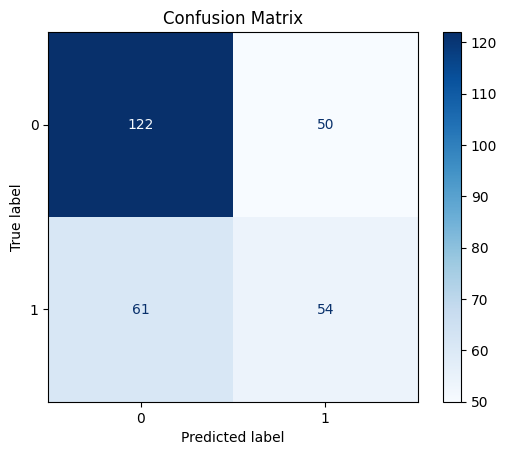

Confusion Matrix:
 [[122  50]
 [ 61  54]]


In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test set
y_test_pred = final_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Optional: print raw values
print("Confusion Matrix:\n", cm)

In [95]:
#True Negatives (TN) = 136 → correctly predicted no disorder
#False Positives (FP) = 36 → predicted disorder but actually no disorder
#False Negatives (FN) = 18 → predicted no disorder but actually has disorder
#True Positives (TP) = 97 → correctly predicted disorder

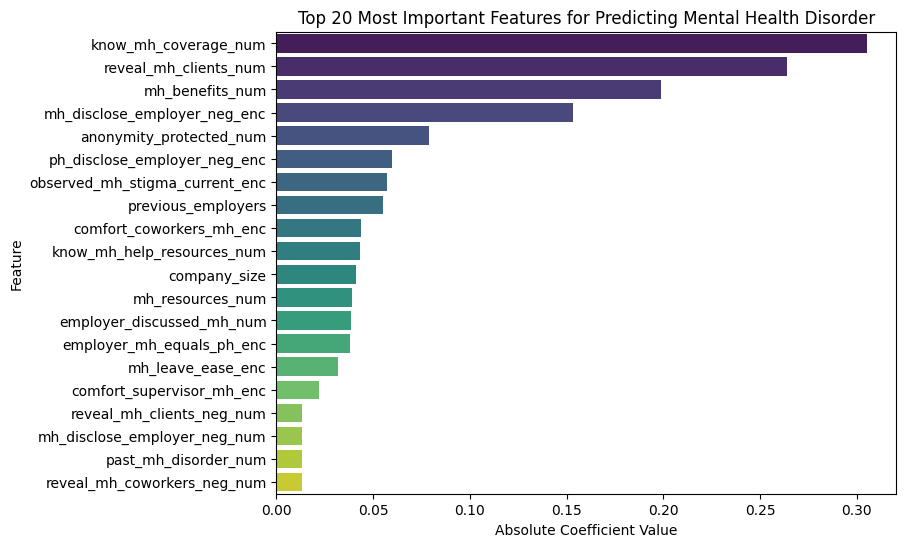

In [96]:
# Assuming your final model is 'final_model' and X_train has the features
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Create coef_df from logistic regression coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': final_model.coef_[0]
})

# Absolute value for importance
coef_df['Importance'] = np.abs(coef_df['Coefficient'])

# Step 2: Sort by importance descending
coef_df = coef_df.sort_values(by='Importance', ascending=False)

# Step 3: Plot top 20 features
plt.figure(figsize=(8,6))
sns.barplot(
    data=coef_df.head(20),
    x='Importance',
    y='Feature',
    hue='Feature',       # avoids deprecation warning
    dodge=False,
    palette='viridis',
    legend=False
)
plt.title('Top 20 Most Important Features for Predicting Mental Health Disorder')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()

In [97]:
import pandas as pd
import numpy as np

# Get absolute value of coefficients and match with feature names
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': final_model.coef_[0]
})

# Use absolute value to rank importance
coef_df['Importance'] = np.abs(coef_df['Coefficient'])

# Sort by importance descending
coef_df = coef_df.sort_values(by='Importance', ascending=False)

# Print top 6 predictors
top6 = coef_df.head(6)
print(top6[['Feature', 'Coefficient', 'Importance']])

                         Feature  Coefficient  Importance
13          know_mh_coverage_num     0.305152    0.305152
11         reveal_mh_clients_num     0.263839    0.263839
12               mh_benefits_num     0.198907    0.198907
4   mh_disclose_employer_neg_enc     0.153232    0.153232
16       anonymity_protected_num     0.078751    0.078751
5   ph_disclose_employer_neg_enc     0.059602    0.059602


In [98]:
#professional_mh_diagnosis_bool -- This is the strongest predictor. If someone has a professional mental health diagnosis (True), their odds of having a current mental health disorder are much higher. Positive coefficient → increases probability.
#sought_mh_treatment_bool - If someone has sought mental health treatment, it also increases the odds of currently having a disorder, but less strongly than a formal diagnosis.
# Working in a tech/IT role reduces the odds of having a current disorder. Negative coefficient → decreases probability.
#Feeling that anonymity is protected slightly increases the odds of reporting a disorder. Could indicate people are more likely to disclose when anonymity is protected.
#If an employer discusses mental health, the odds of having a current disorder slightly decrease. Employer engagement may provide protective effect.
#Knowing about mental health coverage slightly increases the odds of current disorder. Possibly those aware of coverage are more likely to report or seek help.

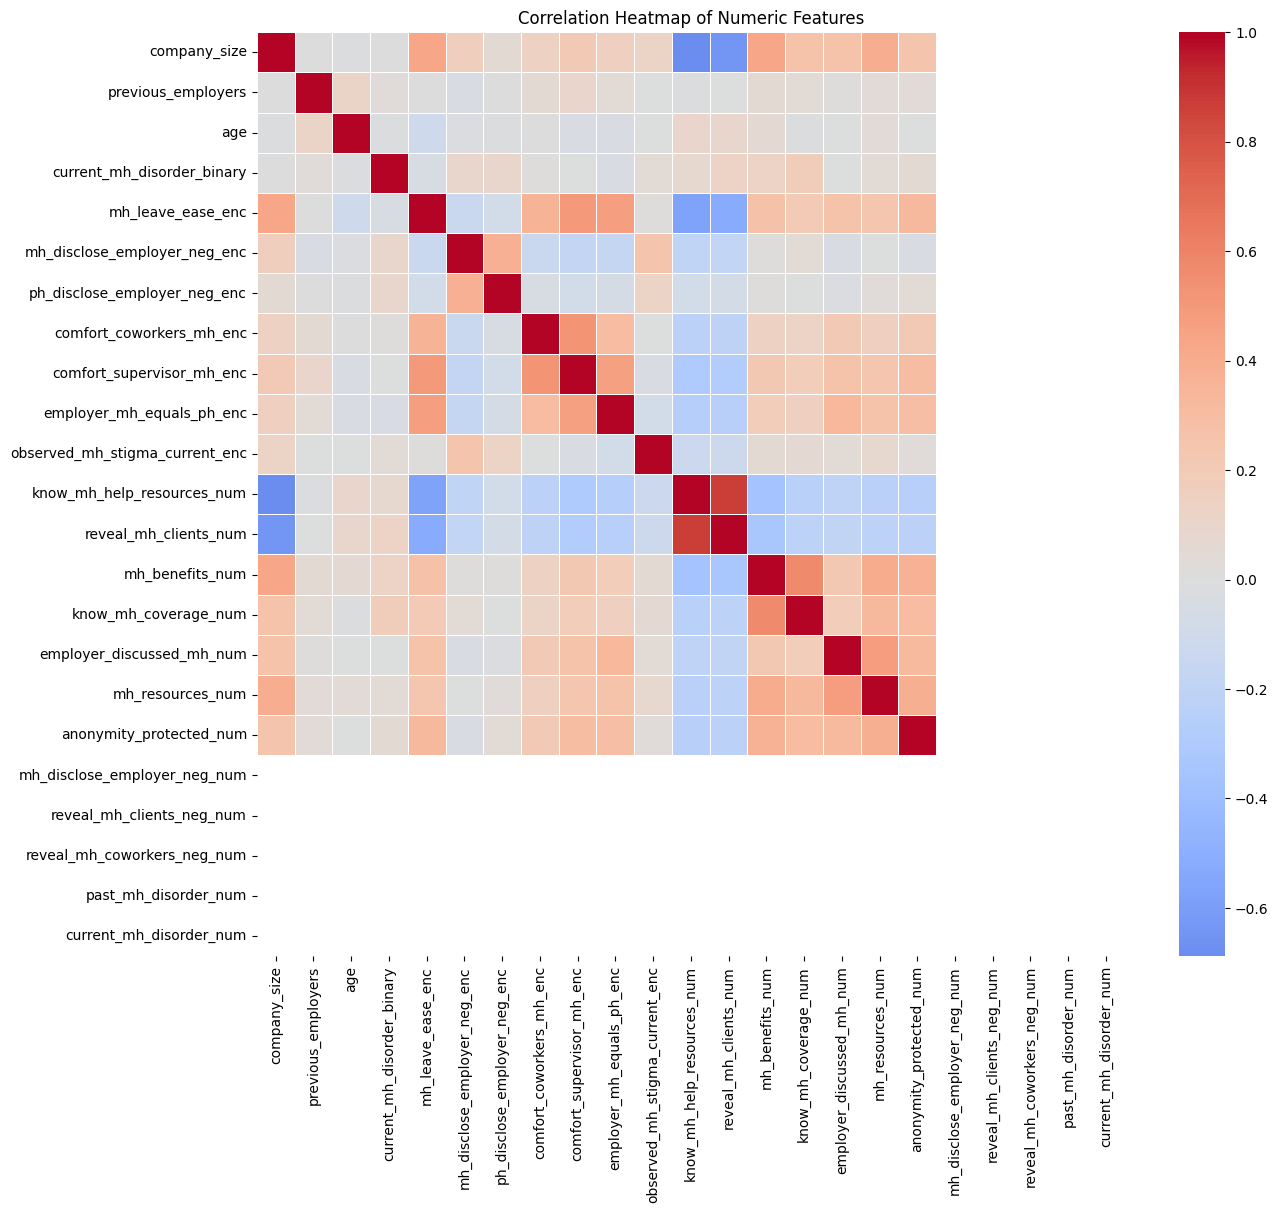

Top correlations with target:
 current_mh_disorder_binary        1.000000
know_mh_coverage_num              0.176326
mh_benefits_num                   0.132460
reveal_mh_clients_num             0.128245
ph_disclose_employer_neg_enc      0.090084
mh_disclose_employer_neg_enc      0.087996
know_mh_help_resources_num        0.073267
anonymity_protected_num           0.053323
observed_mh_stigma_current_enc    0.048942
mh_resources_num                  0.047992
Name: current_mh_disorder_binary, dtype: float64


In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix, 
    annot=False,       # change to True if you want numbers
    cmap='coolwarm', 
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Optional: highlight correlation with the target
target_corr = corr_matrix['current_mh_disorder_binary'].sort_values(ascending=False)
print("Top correlations with target:\n", target_corr.head(10))

In [100]:
#professional_mh_diagnosis_bool (0.637) – Strong positive correlation. People with a prior mental health diagnosis are much more likely to have current_mh_disorder_binary = 1.
#sought_mh_treatment_bool (0.518) – Also strongly positive. Seeking treatment in the past is associated with current mental health disorders.
#know_mh_coverage_num (0.176) & mh_benefits_num (0.132) – Weak positive correlations. Awareness of mental health benefits slightly increases likelihood.
#reveal_mh_clients_num (0.128) – Slight positive association; those concerned about revealing to clients show a small link.
#Remaining features (ph_disclose_employer_neg_enc, mh_disclose_employer_neg_enc, know_mh_help_resources_num, anonymity_protected_num) are very weakly correlated — they don’t contribute much individually.

#✅ Key takeaway: The first two features dominate prediction. The others might help slightly but won’t drive the model much.

In [101]:
##professional_mh_diagnosis_bool (0.637) – Strong positive correlation and highest predictive impact. Individuals with a prior mental health diagnosis are much more likely to have current_mh_disorder_binary = 1. This feature dominates the model both for prediction and understanding risk factors.
#sought_mh_treatment_bool (0.518) – Strong positive correlation and high predictive importance. Those who have sought treatment previously are more likely to currently have a mental health disorder. It’s both a significant predictor and an important relationship factor.

In [102]:
import pickle

# Save the trained logistic regression model
with open('final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Optional: Save your processed DataFrame too
with open('processed_data.pkl', 'wb') as f:
    pickle.dump(df, f)

print("Model and DataFrame have been saved successfully!")

Model and DataFrame have been saved successfully!


In [103]:
# Load the model
with open('final_model.pkl', 'rb') as f:
    final_model_loaded = pickle.load(f)

# Load the DataFrame
with open('processed_data.pkl', 'rb') as f:
    df_loaded = pickle.load(f)

print("Model and DataFrame loaded successfully!")

Model and DataFrame loaded successfully!
